In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
raw_df = pd.read_csv('PSCompPars_2026.03.31_11.13.09.csv')

C:\Users\shank\AppData\Local\Temp\ipykernel_21664\770820807.py:1: DtypeWarning: Columns (82,87,92,104,109,114,119,124,129,150,155) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('PSCompPars_2026.03.31_11.13.09.csv')


In [4]:
raw_df

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,...,sy_kepmagerr1,sy_kepmagerr2,sy_kepmag_reflink,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,2,1,2,0,0,0,0
1,2,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,1,1,0,0,0,0
2,3,14 And b,14 And,b,HD 221345,HIP 116076,TIC 333225860,Gaia DR2 1920113512486282240,Gaia DR3 1920113512486282240,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,1,1,0,0,0,0
3,4,14 Her b,14 Her,b,HD 145675,HIP 79248,TIC 219483057,Gaia DR2 1385293808145621504,Gaia DR3 1385293808145621504,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,1,1,4,1,0,0,0
4,5,16 Cyg B b,16 Cyg B,b,HD 186427,HIP 96901,TIC 27533327,Gaia DR2 2135550755683407232,Gaia DR3 2135550755683407232,3,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5,1,4,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6148,6149,ups And b,ups And,b,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,Gaia DR3 348020482735930112,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5,1,10,1,0,0,0
6149,6150,ups And c,ups And,c,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,Gaia DR3 348020482735930112,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5,1,10,1,0,0,0
6150,6151,ups And d,ups And,d,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,Gaia DR3 348020482735930112,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5,1,10,1,0,0,0
6151,6152,ups Leo b,ups Leo,b,NaN,NaN,TIC 49430557,Gaia DR2 3794167001116433152,Gaia DR3 3794167001116704000,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,0,0,0,0,0,0


---
For calulating ESI of exoplanets, I considered mass (M) and radius (R)

According to _Earth Similarity Index (ESI)_ on PHL (Planetary Habitability Laboratory) Website, 

**"...A mass-radius relationship can also be used for this conversion, but it is not usually necessary since it gives similar results within the interest values(i.e., close to ESI = 1.0)."**

So we assume **Radius (R) is approximatey equal to Cube Root of Mass (M)**  



---

In [5]:
esi_df = raw_df[['pl_name','pl_rade','pl_bmasse']]

In [6]:
esi_df.head()

,pl_name,pl_rade,pl_bmasse
0,11 Com b,12.2,4914.898486
1,11 UMi b,12.3,4684.814200
2,14 And b,13.1,1131.151301
3,14 Her b,12.5,2828.672822
4,16 Cyg B b,13.5,565.737400


In [7]:
esi_df[esi_df['pl_rade'].isnull() & esi_df['pl_bmasse'].isnull()]

,pl_name,pl_rade,pl_bmasse
1939,KIC 10001893 b,NaN,NaN
1940,KIC 10001893 c,NaN,NaN
1941,KIC 10001893 d,NaN,NaN
4918,LkCa 15 b,NaN,NaN
4919,LkCa 15 c,NaN,NaN
4959,MWC 758 c,NaN,NaN
5306,TOI-1634 c,NaN,NaN


**NOTE:** 

I dropped all records that do not have both Mass (M) and Radius (R) because the ESI Formula is computed using Radius (R), Density, Escape Velocity and Surface Temperature.

We can use stellar flux or other parameters instead of those missing, but I want to keep it traditional, hence dropped

In [8]:
#Checking if we have any null values for both radius and mass
esi_df[esi_df['pl_rade'].isnull() & esi_df['pl_bmasse'].isnull()]

,pl_name,pl_rade,pl_bmasse
1939,KIC 10001893 b,NaN,NaN
1940,KIC 10001893 c,NaN,NaN
1941,KIC 10001893 d,NaN,NaN
4918,LkCa 15 b,NaN,NaN
4919,LkCa 15 c,NaN,NaN
4959,MWC 758 c,NaN,NaN
5306,TOI-1634 c,NaN,NaN


In [9]:
esi_df = esi_df.dropna(subset=['pl_rade','pl_bmasse'], thresh=1)

In [10]:
esi_df

,pl_name,pl_rade,pl_bmasse
0,11 Com b,12.2,4914.898486
1,11 UMi b,12.3,4684.814200
2,14 And b,13.1,1131.151301
3,14 Her b,12.5,2828.672822
4,16 Cyg B b,13.5,565.737400
...,...,...,...
6148,ups And b,14.0,218.531000
6149,ups And c,12.3,4443.241130
6150,ups And d,12.5,3257.741172
6151,ups Leo b,14.2,162.092488


### Radius-Mass Relation

Since we are looking for exoplanets similar to Earth in size, we filter out gas giants and sub-Neptunes with:

    R ≤ 1.6 R⊕

Planets below this threshold are rocky in composition, as 
established by the observed "radius gap" in the Kepler planet population 
(Fulton et al., 2017). 

Above 1.6 R⊕, planets tend to retain thick 
hydrogen/helium envelopes, making them structurally unlike Earth.

However, not all planets in the dataset have both radius and mass recorded. 
For planets missing mass values, mass is estimated using the empirical 
power-law from *Chen & Kipping (2017)* for the rocky planet regime:

    M = 0.9718 × R^3.58   (M in M⊕, R in R⊕)

For planets missing radius values, the relation is inverted:

    R = (M / 0.9718)^(1/3.58)   (R in R⊕, M in M⊕)


This accounts for gravitational compression — unlike a constant-density 
assumption (M ∝ R³), real rocky planets get denser as mass increases, 
meaning radius grows more slowly than naive models predict (R ∝ M^0.28 
rather than R ∝ M^(1/3)).

**Limitation:** ESI parameters derived from estimated mass or radius values 
carry this approximation as an inherited uncertainty.

In [11]:
esi_df[esi_df['pl_rade']>1.6]

,pl_name,pl_rade,pl_bmasse
0,11 Com b,12.2,4914.898486
1,11 UMi b,12.3,4684.814200
2,14 And b,13.1,1131.151301
3,14 Her b,12.5,2828.672822
4,16 Cyg B b,13.5,565.737400
...,...,...,...
6148,ups And b,14.0,218.531000
6149,ups And c,12.3,4443.241130
6150,ups And d,12.5,3257.741172
6151,ups Leo b,14.2,162.092488


4857 Exoplanets do not come under Terrestrial Regime -> Drop these records

In [12]:
esi_df = esi_df[esi_df['pl_rade'] <= 1.6]

In [13]:
esi_df.head()

,pl_name,pl_rade,pl_bmasse
56,AU Mic d,1.020,1.053
90,Barnard b,0.720,0.299
91,Barnard c,0.743,0.335
92,Barnard d,0.694,0.263
93,Barnard e,0.637,0.193


**NOTE:** Filtering was applied directly to the reported numerical radius values without rounding; therefore, minor differences in the final record count arose due to numerical precision.

In [14]:
#The Radius-Mass Relation Definition
def radius_mass_relation(pl_rade, pl_bmasse):
    if np.isnan(pl_bmasse) and not np.isnan(pl_rade):
        pl_bmasse = 0.9718 * (pl_rade ** 3.58)
    elif np.isnan(pl_rade) and not np.isnan(pl_bmasse):
        pl_rade = (pl_bmasse / 0.9718) ** (1 / 3.58)
    return pl_rade, pl_bmasse

radius_mass_rel = np.vectorize(radius_mass_relation)
result = radius_mass_rel(esi_df['pl_rade'],esi_df['pl_bmasse'])
esi_df['pl_rade'] = result[0]
esi_df['pl_bmasse'] = result[1]

C:\Users\shank\AppData\Local\Temp\ipykernel_21664\660728321.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  esi_df['pl_rade'] = result[0]
C:\Users\shank\AppData\Local\Temp\ipykernel_21664\660728321.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  esi_df['pl_bmasse'] = result[1]


In [15]:
esi_df

,pl_name,pl_rade,pl_bmasse
56,AU Mic d,1.020,1.053
90,Barnard b,0.720,0.299
91,Barnard c,0.743,0.335
92,Barnard d,0.694,0.263
93,Barnard e,0.637,0.193
...,...,...,...
6102,YZ Cet b,0.913,0.700
6103,YZ Cet c,1.050,1.140
6104,YZ Cet d,1.030,1.090
6145,tau Cet g,1.180,1.750


Now that we have atleast Mass (M) or Radius (R), we can calculate Density, but since we cannot directly measure the surface temperature of exoplanets.

We will use **Equilibrium Temperature[K]** *(eqt for short), if any null values in eqt we will calulate it by using its:
* Star's Luminosity (L*) (if missing radius and Temperature of the star),
* planet's abledo,
* orbital distance from the star.

In [16]:
raw_df[raw_df['pl_eqt'].isna()]

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,...,sy_kepmagerr1,sy_kepmagerr2,sy_kepmag_reflink,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,2,1,2,0,0,0,0
1,2,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,1,1,0,0,0,0
2,3,14 And b,14 And,b,HD 221345,HIP 116076,TIC 333225860,Gaia DR2 1920113512486282240,Gaia DR3 1920113512486282240,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,1,1,0,0,0,0
3,4,14 Her b,14 Her,b,HD 145675,HIP 79248,TIC 219483057,Gaia DR2 1385293808145621504,Gaia DR3 1385293808145621504,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,1,1,4,1,0,0,0
4,5,16 Cyg B b,16 Cyg B,b,HD 186427,HIP 96901,TIC 27533327,Gaia DR2 2135550755683407232,Gaia DR3 2135550755683407232,3,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5,1,4,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6148,6149,ups And b,ups And,b,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,Gaia DR3 348020482735930112,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5,1,10,1,0,0,0
6149,6150,ups And c,ups And,c,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,Gaia DR3 348020482735930112,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5,1,10,1,0,0,0
6150,6151,ups And d,ups And,d,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,Gaia DR3 348020482735930112,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5,1,10,1,0,0,0
6151,6152,ups Leo b,ups Leo,b,NaN,NaN,TIC 49430557,Gaia DR2 3794167001116433152,Gaia DR3 3794167001116704000,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,0,0,0,0,0,0


Since it has so many Null values, 

Step 1: Calculate eqt

Reuired Parameters:
* Stellar Luminosity (st_lum),
* Stellar radius(st_rad) and temperature(st_teff) (in case Luminosity is a null value) -> `st_lum = st_rad^2 * st_teff^4`
* Albedo (Not in dataset,therefore we assume it as 0.3),
* Orbital Distance - Semi Major Axis (pl_orbsmax)
    
Step 2: Checking if we can calculate eqt, if not then drop those records

Step 3: Finding Escape velocity

---

In [17]:
raw_df[['pl_eqt','st_lum','st_rad','st_teff','pl_orbsmax']].head()

,pl_eqt,st_lum,st_rad,st_teff,pl_orbsmax
0,NaN,1.97823,13.76,4874.0,1.178
1,NaN,2.42951,29.79,4213.0,1.530
2,NaN,1.83992,11.55,4888.0,0.775
3,NaN,-0.15273,0.93,5338.0,2.839
4,NaN,0.09729,1.13,5750.0,1.660


In [18]:
def missing_eqt(pl_eqt, st_lum, st_rad, st_teff, pl_orbsmax):
    albedo = 0.3
    
    # Convert st_lum from log10 to linear if it exists
    if not np.isnan(st_lum):
        lum_linear = 10 ** st_lum
    # Calculate luminosity from radius and temperature if st_lum is missing
    elif np.isnan(st_lum) and (not np.isnan(st_rad) and not np.isnan(st_teff)):
        # Stefan-Boltzmann: L/L_sun = (R/R_sun)^2 * (T/T_sun)^4
        # Assuming st_rad is in solar radii and st_teff in Kelvin
        T_sun = 5778  # K
        lum_linear = (st_rad ** 2) * ((st_teff / T_sun) ** 4)
    else:
        lum_linear = np.nan
    
    # Calculate equilibrium temperature if missing
    if np.isnan(pl_eqt) and (not np.isnan(lum_linear) and not np.isnan(pl_orbsmax)):
        pl_eqt = 278.5 * ((1 - albedo) ** 0.25) * (lum_linear ** 0.25) / (pl_orbsmax ** 0.5)
    
    return pl_eqt


calculate_eqt = np.vectorize(missing_eqt)
raw_df['pl_eqt'] = calculate_eqt(raw_df['pl_eqt'], raw_df['st_lum'], raw_df['st_rad'], raw_df['st_teff'], raw_df['pl_orbsmax'])

In [19]:
raw_df[raw_df['pl_eqt'].isna()]

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,...,sy_kepmagerr1,sy_kepmagerr2,sy_kepmag_reflink,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
12,13,2MASS J01033563-5515561 AB b,2MASS J01033563-5515561 A,b,NaN,NaN,TIC 206502540,NaN,NaN,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,1,0,0,0,0,0,1
53,54,AT2021ueyL b,AT2021ueyL,b,NaN,NaN,NaN,NaN,NaN,1,...,NaN,NaN,<a refstr=BAN_ET_AL__2025 href=https://ui.adsa...,0,0,0,0,0,0,0
56,57,AU Mic d,AU Mic,d,HD 197481,HIP 102409,TIC 441420236,Gaia DR2 6794047652729201024,Gaia DR3 6794047652729201024,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,1,1,0,1,0,0,0
57,58,AU Mic e,AU Mic,e,HD 197481,HIP 102409,TIC 441420236,Gaia DR2 6794047652729201024,Gaia DR3 6794047652729201024,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,2,1,0,1,0,0,0
98,99,CHXR 73 b,CHXR 73,b,NaN,NaN,TIC 454291479,Gaia DR2 5201175987817179136,Gaia DR3 5201175987817179136,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5896,5897,WASP-107 c,WASP-107,c,NaN,NaN,TIC 429302040,Gaia DR2 3578638842054261248,Gaia DR3 3578638842054261248,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,1,0,0,0,0,0,0
5912,5913,WASP-126 c,WASP-126,c,NaN,NaN,TIC 25155310,Gaia DR2 4666498154837086208,Gaia DR3 4666498154837086208,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,0,0,0,0,0,0
6105,6106,ZTF J1230-2655 b,ZTF J1230-2655,b,NaN,NaN,TIC 951438622,Gaia DR2 3475360576690175616,Gaia DR3 3475360576690175616,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,0,0,0,0,0,0
6106,6107,ZTF J1828+2308 b,ZTF J1828+2308,b,NaN,NaN,TIC 1685332572,Gaia DR2 4529477698683435264,Gaia DR3 4529477698683435264,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0,0,0,0,0,0,0


Approach after this:
1. merge raw_df and esi_df first
2. then drop the eqt = NaN records directly

Then calculate escape vel.

*this markdown has to be removed

In [20]:
esi_df = pd.merge(left = esi_df, right = raw_df[['pl_name','pl_eqt','st_lum','st_rad','st_teff','pl_orbsmax','pl_orbper','st_mass','st_age']], how = "inner", on = "pl_name")
esi_df

,pl_name,pl_rade,pl_bmasse,pl_eqt,st_lum,st_rad,st_teff,pl_orbsmax,pl_orbper,st_mass,st_age
0,AU Mic d,1.020,1.053,NaN,-1.03810,0.744,3678.0,NaN,12.73596,0.510,0.0201
1,Barnard b,0.720,0.299,438.000000,-2.44977,0.185,3195.0,0.02290,3.15420,0.162,NaN
2,Barnard c,0.743,0.335,400.000000,-2.44977,0.185,3195.0,0.02740,4.12440,0.162,NaN
3,Barnard d,0.694,0.263,483.000000,-2.44977,0.185,3195.0,0.01880,2.34020,0.162,NaN
4,Barnard e,0.637,0.193,340.000000,-2.44977,0.185,3195.0,0.03810,6.73920,0.162,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1179,YZ Cet b,0.913,0.700,471.200000,-2.65857,0.157,3151.0,0.01634,2.02087,0.142,3.8000
1180,YZ Cet c,1.050,1.140,410.300000,-2.65857,0.157,3151.0,0.02156,3.05989,0.142,3.8000
1181,YZ Cet d,1.030,1.090,356.700000,-2.65857,0.157,3151.0,0.02851,4.65626,0.142,3.8000
1182,tau Cet g,1.180,1.750,585.903900,-0.30539,0.830,5310.0,0.13300,20.00000,0.783,12.1200


In [21]:
esi_df = esi_df.dropna(subset = ['pl_eqt'])

In [22]:
esi_df

,pl_name,pl_rade,pl_bmasse,pl_eqt,st_lum,st_rad,st_teff,pl_orbsmax,pl_orbper,st_mass,st_age
1,Barnard b,0.720,0.299,438.000000,-2.44977,0.185,3195.0,0.02290,3.15420,0.162,NaN
2,Barnard c,0.743,0.335,400.000000,-2.44977,0.185,3195.0,0.02740,4.12440,0.162,NaN
3,Barnard d,0.694,0.263,483.000000,-2.44977,0.185,3195.0,0.01880,2.34020,0.162,NaN
4,Barnard e,0.637,0.193,340.000000,-2.44977,0.185,3195.0,0.03810,6.73920,0.162,NaN
5,DMPP-3 A b,1.440,2.670,854.000000,-0.29513,0.910,5138.0,0.05958,5.59000,0.900,10.90
...,...,...,...,...,...,...,...,...,...,...,...
1179,YZ Cet b,0.913,0.700,471.200000,-2.65857,0.157,3151.0,0.01634,2.02087,0.142,3.80
1180,YZ Cet c,1.050,1.140,410.300000,-2.65857,0.157,3151.0,0.02156,3.05989,0.142,3.80
1181,YZ Cet d,1.030,1.090,356.700000,-2.65857,0.157,3151.0,0.02851,4.65626,0.142,3.80
1182,tau Cet g,1.180,1.750,585.903900,-0.30539,0.830,5310.0,0.13300,20.00000,0.783,12.12


Exoplanets with no calculatable Equilibrium Temperature are dropped.

---

In our dataset, *pl_rade and pl_bmasse* are in Earth Radius and Earth Mass,  
Since Gravitational Constant "G" is defined in SI units, both values will be convert them to kg and meter respectively before applying to Escape Velocity formula.

`1 Earth mass = 5.972 x 10^24kg`
`1 Earth Radius = 6.371 x 10^6m`

---

In [23]:
def escape_velocity(pl_rade,pl_bmasse):
    e_mass = 5.972e24 #Earth Mass
    e_rad = 6.371e6   #Earth Radius
    G = 6.674e-11     #Universal Gravitatinal Constant

    pl_bmasse = pl_bmasse*e_mass
    pl_rade = pl_rade*e_rad

    esc_vel = np.sqrt((2 * 6.674e-11 * (pl_bmasse)) / (pl_rade))

    return esc_vel


esc_vel = np.vectorize(escape_velocity)
esi_df['pl_escvel'] = esc_vel(esi_df['pl_rade'], esi_df['pl_bmasse'])
esi_df.head()

C:\Users\shank\AppData\Local\Temp\ipykernel_21664\3706604380.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  esi_df['pl_escvel'] = esc_vel(esi_df['pl_rade'], esi_df['pl_bmasse'])


,pl_name,pl_rade,pl_bmasse,pl_eqt,st_lum,st_rad,st_teff,pl_orbsmax,pl_orbper,st_mass,st_age,pl_escvel
1,Barnard b,0.720,0.299,438.0,-2.44977,0.185,3195.0,0.02290,3.1542,0.162,NaN,7208.311433
2,Barnard c,0.743,0.335,400.0,-2.44977,0.185,3195.0,0.02740,4.1244,0.162,NaN,7510.903680
3,Barnard d,0.694,0.263,483.0,-2.44977,0.185,3195.0,0.01880,2.3402,0.162,NaN,6885.925743
4,Barnard e,0.637,0.193,340.0,-2.44977,0.185,3195.0,0.03810,6.7392,0.162,NaN,6157.056435
5,DMPP-3 A b,1.440,2.670,854.0,-0.29513,0.910,5138.0,0.05958,5.5900,0.900,10.9,15231.356409


In [24]:
esi_df['pl_escvel'].describe()

count      1120.000000
mean      16565.771509
std       29334.787966
min        2682.758951
25%       12309.429139
50%       14640.822575
75%       15415.736542
max      679087.590119
Name: pl_escvel, dtype: float64

In [25]:
def calculate_density(pl_bmasse, pl_rade):
    
    # Convert to SI units
    e_mass = 5.972e24   # kg
    e_rad = 6.371e6     # meters

    mass_kg   = pl_bmasse * e_mass
    radius_m  = pl_rade * e_rad

    # Volume in m3
    volume_m3 = (4/3) * np.pi * (radius_m ** 3)

    # Density in kg/m3 then convert to g/cm3
    density_kgm3 = mass_kg / volume_m3
    density_gcm3 = density_kgm3 / 1000  # kg/m3 → g/cm3

    return density_gcm3


density = np.vectorize(calculate_density)
esi_df['pl_dens'] = density(esi_df['pl_bmasse'], esi_df['pl_rade'])

# Filter out unrealistic densities (Earth is 5.51, densest known planets ~15-20)
esi_df = esi_df[esi_df['pl_dens'] <= 20]


C:\Users\shank\AppData\Local\Temp\ipykernel_21664\2741996352.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  esi_df['pl_dens'] = density(esi_df['pl_bmasse'], esi_df['pl_rade'])


In [26]:
esi_df

,pl_name,pl_rade,pl_bmasse,pl_eqt,st_lum,st_rad,st_teff,pl_orbsmax,pl_orbper,st_mass,st_age,pl_escvel,pl_dens
1,Barnard b,0.720,0.299,438.000000,-2.44977,0.185,3195.0,0.02290,3.15420,0.162,NaN,7208.311433,4.416539
2,Barnard c,0.743,0.335,400.000000,-2.44977,0.185,3195.0,0.02740,4.12440,0.162,NaN,7510.903680,4.502842
3,Barnard d,0.694,0.263,483.000000,-2.44977,0.185,3195.0,0.01880,2.34020,0.162,NaN,6885.925743,4.337962
4,Barnard e,0.637,0.193,340.000000,-2.44977,0.185,3195.0,0.03810,6.73920,0.162,NaN,6157.056435,4.116683
5,DMPP-3 A b,1.440,2.670,854.000000,-0.29513,0.910,5138.0,0.05958,5.59000,0.900,10.90,15231.356409,4.929832
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,YZ Cet b,0.913,0.700,471.200000,-2.65857,0.157,3151.0,0.01634,2.02087,0.142,3.80,9794.399791,5.071006
1180,YZ Cet c,1.050,1.140,410.300000,-2.65857,0.157,3151.0,0.02156,3.05989,0.142,3.80,11655.260164,5.429319
1181,YZ Cet d,1.030,1.090,356.700000,-2.65857,0.157,3151.0,0.02851,4.65626,0.142,3.80,11506.913081,5.499500
1182,tau Cet g,1.180,1.750,585.903900,-0.30539,0.830,5310.0,0.13300,20.00000,0.783,12.12,13622.042053,5.872194


---
## **ESI - Earth Similarity Index**

ESI is used to measure *earth-likeness* for solar or extrasolar planets.
It ranges from 0 to 1,
1 being identical to earth and 0 meaning no similarity

Planets above 0.8 can be considered earth-like planets, 
between 0.6 - 0.8, they might still be considered habitable



Formula:

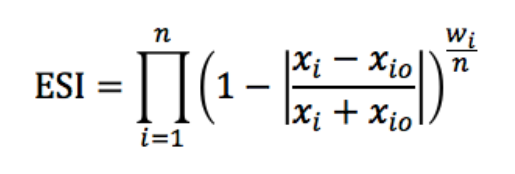

Here,

* xi = planetary property (radius, density, equilibrium temperature and escape velocity)
* xio = terrestrial reference
* wi = weight exponent
* n = no.of planetary properties


**Weight Exponents:** 

"The weighting exponents are used to adjust the sensitivity of the scale and equalize its meaning between different properties." (https://phl.upr.edu/projects/earth-similarity-index-esi)

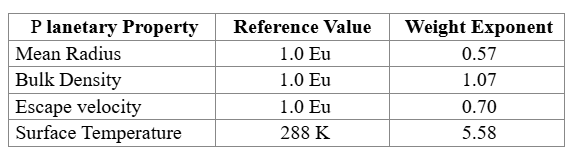
Note: Eu = Earth's Units

In [27]:
#Before this, convert pl_escvel and and pl_dens to Eu and the run this function 

def calculate_esi(pl_rade, pl_dens, pl_escvel, pl_eqt):
    
    # Earth reference values
    earth_radius   = 1.0      # Earth radii
    earth_density  = 5.51     # g/cm3
    earth_escvel   = 11186.0  # m/s
    earth_temp     = 255.0    # K

    # Weights
    w_radius  = 0.57
    w_density = 1.07
    w_escvel  = 0.70
    w_temp    = 5.58
    n         = 4  # number of properties

    # ESI term for each property
    def esi_term(x, x_earth, weight):
        return (1 - abs((x - x_earth) / (x + x_earth))) ** (weight / n)

    esi = (
        esi_term(pl_rade,    earth_radius,  w_radius)  *
        esi_term(pl_dens,    earth_density, w_density) *
        esi_term(pl_escvel,  earth_escvel,  w_escvel)  *
        esi_term(pl_eqt,     earth_temp,    w_temp)
    )

    return esi


esi_vec = np.vectorize(calculate_esi)
esi_df['esi'] = esi_vec(
    esi_df['pl_rade'],
    esi_df['pl_dens'],
    esi_df['pl_escvel'],
    esi_df['pl_eqt']
)

C:\Users\shank\AppData\Local\Temp\ipykernel_21664\3503311175.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  esi_df['esi'] = esi_vec(


In [28]:
esi_df['esi'].describe()

count    1067.000000
mean        0.341698
std         0.181639
min         0.022637
25%         0.218440
50%         0.290373
75%         0.417150
max         0.974170
Name: esi, dtype: float64

In [29]:
top_planets = esi_df[['pl_name', 'pl_rade', 'pl_eqt', 'pl_escvel', 'pl_dens', 'esi']]\
    .sort_values('esi', ascending=False)\
    .head(10)

top_planets

,pl_name,pl_rade,pl_eqt,pl_escvel,pl_dens,esi
1177,Wolf 1069 b,1.080,250.100000,12081.965487,5.514519,0.974170
1169,TRAPPIST-1 e,0.920,249.700000,9701.152453,4.899491,0.951359
1160,TOI-700 d,1.073,268.800000,12073.115113,5.578523,0.950452
1161,TOI-700 e,0.953,272.900000,10363.212355,5.210543,0.936145
1173,Teegarden's Star b,1.050,277.000000,11757.054762,5.524570,0.935010
589,Kepler-1649 c,1.060,234.000000,11901.505081,5.554846,0.930494
32,GJ 1002 b,1.030,230.900000,11454.007453,5.449046,0.926202
929,Kepler-442 b,1.340,241.000000,14844.576026,5.407618,0.912707
198,K2-72 e,1.290,271.809278,14640.822575,5.675858,0.910594
42,GJ 273 b,1.510,258.498566,15474.785708,4.627808,0.907602


Here are my Top 10 Exoplanets that are the most similar to earth.
My Calculation differ from PHL's Habitable Worlds Catelog rankings because of the methodology used.


I used *Equilibrium Temperature* whereas PHL uses *Estimated Surface Temperature*




---

## **Habitabile Zone Distance**

Now that we have ESI of exoplanets, we can calculate the HZD - Habitabile Zone Distance, it is a measure of how far a planet is from its star's habitable zone

If:
* HZD == 0, Planet is in the habitable zone
* HZD == -1, the planet is too near, i.e. too hot
* HZD == +1, the planet is too far, i.e. too cold
* HZD == 1, the planet is outside the habitable zone

**Formula**

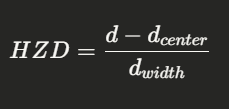

where,

* d = planets orbital distance (pl_orbsmax)
* d-center = center of habitable zone    `d(inner) + d(outer)/2`
* d-width = width of the habitable zone  `d(inner) - d(outer)/2`

*d(inner)* and *d(outer)* can be calculated using Stellar Luminosity:

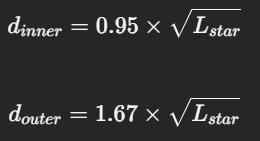

**Required Parameters:**
* Planets orbital Distance (pl_orbsmax)
* Stellar Luminosity (st_lum)

In [30]:

esi_df[['pl_name','pl_orbsmax','st_lum']]

,pl_name,pl_orbsmax,st_lum
1,Barnard b,0.02290,-2.44977
2,Barnard c,0.02740,-2.44977
3,Barnard d,0.01880,-2.44977
4,Barnard e,0.03810,-2.44977
5,DMPP-3 A b,0.05958,-0.29513
...,...,...,...
1179,YZ Cet b,0.01634,-2.65857
1180,YZ Cet c,0.02156,-2.65857
1181,YZ Cet d,0.02851,-2.65857
1182,tau Cet g,0.13300,-0.30539


In [31]:
def calculate_hzd(pl_orbsmax, st_lum, pl_orbper, st_mass):
    # Check if st_lum is valid
    if np.isnan(st_lum):
        return np.nan
    
    # Convert from log10 scale to linear scale
    lum = 10 ** st_lum
    
    # Derive pl_orbsmax from Kepler's law if missing
    if np.isnan(pl_orbsmax):
        if not np.isnan(pl_orbper) and not np.isnan(st_mass):
            pl_orbsmax = ((pl_orbper / 365.25) ** 2 * st_mass) ** (1/3)
        else:
            return np.nan
    
    # Habitable zone boundaries (in AU)
    d_inner = 0.95 * np.sqrt(lum)
    d_outer = 1.67 * np.sqrt(lum)
    
    # Habitable zone center and width
    d_center = (d_inner + d_outer) / 2
    d_width  = (d_outer - d_inner) / 2
    
    # HZD
    hzd = (pl_orbsmax - d_center) / d_width
    
    return hzd



hzd_vec = np.vectorize(calculate_hzd)
esi_df['hzd'] = hzd_vec(
    esi_df['pl_orbsmax'],
    esi_df['st_lum'],
    esi_df['pl_orbper'],
    esi_df['st_mass']
)

C:\Users\shank\AppData\Local\Temp\ipykernel_21664\1941572853.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  esi_df['hzd'] = hzd_vec(


In [32]:
print(esi_df['hzd'].describe())

count    1067.000000
mean       -3.191309
std         0.743560
min        -3.635407
25%        -3.514117
50%        -3.424309
75%        -3.217868
max         4.538299
Name: hzd, dtype: float64


In [33]:
# Check your top ESI planets
print(esi_df[['pl_name', 'hzd', 'esi']]
      .sort_values('esi', ascending=False)
      .head(10))

                 pl_name       hzd       esi
1177         Wolf 1069 b -0.198585  0.974170
1169        TRAPPIST-1 e -0.183807  0.951359
1160           TOI-700 d -0.641358  0.950452
1161           TOI-700 e -1.179188  0.936145
1173  Teegarden's Star b -0.961403  0.935010
589        Kepler-1649 c -1.129216  0.930494
32             GJ 1002 b -0.253421  0.926202
929         Kepler-442 b -0.316727  0.912707
198              K2-72 e -1.199009  0.910594
42              GJ 273 b -0.941270  0.907602


In [34]:
print("Shape:", esi_df.shape)

print("\n--- Missing Values ---")
print(esi_df[['pl_eqt', 'pl_escvel', 'pl_dens', 'st_lum', 'pl_orbsmax', 'esi', 'hzd']].isna().sum())

print("\n--- Key Stats ---")
print(esi_df[['pl_eqt', 'pl_escvel', 'pl_dens', 'esi', 'hzd']].describe())

print("\n--- Top 10 by ESI ---")
print(esi_df[['pl_name', 'pl_rade', 'pl_eqt', 'pl_escvel', 'pl_dens', 'esi', 'hzd']]
      .sort_values('esi', ascending=False)
      .head(10))

Shape: (1067, 15)

--- Missing Values ---
pl_eqt         0
pl_escvel      0
pl_dens        0
st_lum         0
pl_orbsmax    31
esi            0
hzd            0
dtype: int64

--- Key Stats ---
            pl_eqt     pl_escvel      pl_dens          esi          hzd
count  1067.000000   1067.000000  1067.000000  1067.000000  1067.000000
mean    976.736501  13656.721565     5.503676     0.341698    -3.191309
std     508.168610   3118.565776     1.695044     0.181639     0.743560
min     159.000000   2682.758951     0.248363     0.022637    -3.635407
25%     650.396913  12041.570972     4.744904     0.218440    -3.514117
50%     930.000000  14553.973019     5.304043     0.290373    -3.424309
75%    1200.000000  15297.306116     5.769657     0.417150    -3.217868
max    7194.888770  31449.535498    19.191198     0.974170     4.538299

--- Top 10 by ESI ---
                 pl_name  pl_rade      pl_eqt     pl_escvel   pl_dens  \
1177         Wolf 1069 b    1.080  250.100000  12081.965487  5.

In [35]:
print(esi_df['hzd'].describe())

count    1067.000000
mean       -3.191309
std         0.743560
min        -3.635407
25%        -3.514117
50%        -3.424309
75%        -3.217868
max         4.538299
Name: hzd, dtype: float64


In [36]:
# Only planets within the habitable zone
esi_hzd_df = esi_df[esi_df['hzd'].between(-1, 1)].sort_values('hzd',ascending=True)


In [37]:
esi_hzd_df[['pl_name','esi','hzd']]

,pl_name,esi,hzd
1066,L 98-59 f,0.851529,-0.993234
789,Kepler-296 e,0.741302,-0.972618
511,Kepler-1512 b,0.808749,-0.961595
1173,Teegarden's Star b,0.935010,-0.961403
42,GJ 273 b,0.907602,-0.941270
1160,TOI-700 d,0.950452,-0.641358
591,Kepler-1652 b,0.868743,-0.610351
1162,TOI-715 b,0.854830,-0.348323
929,Kepler-442 b,0.912707,-0.316727
32,GJ 1002 b,0.926202,-0.253421


Here, HZD gives us a score that ranges from -1 to +1, but for calculating habitability, we need a score that ranges from 0 to 1, just like ESI(where, 0 = lowest, 1 = highest)

We can do `HZD = 1 - abs(HZD)`


In [38]:
def hzd(hzd):
    return (1 - abs(hzd))**0.5

hzd_score = np.vectorize(hzd)
esi_hzd_df['hzd'] = hzd_score(esi_hzd_df['hzd'])

In [39]:
esi_hzd_df[['pl_name','esi','hzd']]

,pl_name,esi,hzd
1066,L 98-59 f,0.851529,0.082257
789,Kepler-296 e,0.741302,0.165474
511,Kepler-1512 b,0.808749,0.195973
1173,Teegarden's Star b,0.935010,0.196462
42,GJ 273 b,0.907602,0.242343
1160,TOI-700 d,0.950452,0.598867
591,Kepler-1652 b,0.868743,0.624219
1162,TOI-715 b,0.854830,0.807265
929,Kepler-442 b,0.912707,0.826603
32,GJ 1002 b,0.926202,0.864048


We have ESI and HZD scores ready, but just by knowing how earth-like the planet is and how far is it from its star wont tell us if it is habiltable or not. We also have to calulate PHI - Planetary Habitability Index.

---
ESI and HZD are the core parameters of filtering in this process, planets with ESI <= 7.5 and HZD >= 0.71. 

ESI and HZD need to be filtered strictly, so planets with ESI less than 7.5 are not structurally similar to Earth and HZD has to be strictly >= 0.71 because the planet's placement has to be well within the host star's habitable zone, if we consider values like >= 0.5, then they suggest that the planets near that value are reasonably well-placed within the HZ, not just barely inside the boundary. So having it strictly limited to >=0.71 will give us planets that are well withing the HZ and not near boundaries.

In [40]:
esi_hzd_df

,pl_name,pl_rade,pl_bmasse,pl_eqt,st_lum,st_rad,st_teff,pl_orbsmax,pl_orbper,st_mass,st_age,pl_escvel,pl_dens,esi,hzd
1066,L 98-59 f,1.480,2.800,285.000000,-1.91364,0.3155,3415.0,0.105200,23.064000,0.2923,4.94,15385.526194,4.761911,0.851529,0.082257
789,Kepler-296 e,1.530,2.960,337.000000,-1.50864,0.4800,3740.0,0.169000,34.142110,0.4980,4.20,15558.378622,4.556441,0.741302,0.165474
511,Kepler-1512 b,1.180,1.760,322.000000,-1.69500,0.6700,4372.0,0.136930,20.359726,0.7300,1.78,13660.906731,5.905749,0.808749,0.195973
1173,Teegarden's Star b,1.050,1.160,277.000000,-3.14146,0.1200,3034.0,0.025900,4.906340,0.0970,8.00,11757.054762,5.524570,0.935010,0.196462
42,GJ 273 b,1.510,2.890,258.498566,-2.05552,0.2930,3382.0,0.091101,18.649800,0.2900,NaN,15474.785708,4.627808,0.907602,0.242343
1160,TOI-700 d,1.073,1.250,268.800000,-1.64016,0.4210,3459.0,0.163300,37.423960,0.4150,1.50,12073.115113,5.578523,0.950452,0.598867
591,Kepler-1652 b,1.600,3.190,268.000000,-1.63800,0.3820,3638.0,0.165400,38.097220,0.4040,3.20,15794.269573,4.293773,0.868743,0.624219
1162,TOI-715 b,1.550,3.020,234.000000,-2.30899,0.2400,3075.0,0.083000,19.288004,0.2250,6.20,15613.555753,4.471160,0.854830,0.807265
929,Kepler-442 b,1.340,2.360,241.000000,-0.93200,0.5980,4402.0,0.409000,112.305300,0.6090,2.90,14844.576026,5.407618,0.912707,0.826603
32,GJ 1002 b,1.030,1.080,230.900000,-2.85201,0.1370,3024.0,0.045700,10.346500,0.1200,NaN,11454.007453,5.449046,0.926202,0.864048


In [41]:
def esi_hzd_filtering(esi,hzd):
    if esi >= 0.75 and hzd >= 0.71:
        return True
    else:
        return False

filter_fn = np.vectorize(esi_hzd_filtering)
mask = filter_fn(esi_hzd_df['esi'], esi_hzd_df['hzd'])
esi_hzd_df = esi_hzd_df[mask].reset_index(drop=True)

esi_hzd_df

,pl_name,pl_rade,pl_bmasse,pl_eqt,st_lum,st_rad,st_teff,pl_orbsmax,pl_orbper,st_mass,st_age,pl_escvel,pl_dens,esi,hzd
0,TOI-715 b,1.55,3.020,234.000000,-2.30899,0.2400,3075.0,0.08300,19.288004,0.2250,6.2,15613.555753,4.471160,0.854830,0.807265
1,Kepler-442 b,1.34,2.360,241.000000,-0.93200,0.5980,4402.0,0.40900,112.305300,0.6090,2.9,14844.576026,5.407618,0.912707,0.826603
2,GJ 1002 b,1.03,1.080,230.900000,-2.85201,0.1370,3024.0,0.04570,10.346500,0.1200,NaN,11454.007453,5.449046,0.926202,0.864048
3,Wolf 1069 b,1.08,1.260,250.100000,-2.53106,0.1813,3158.0,0.06720,15.564000,0.1670,NaN,12081.965487,5.514519,0.974170,0.895218
4,TRAPPIST-1 e,0.92,0.692,249.700000,-3.25727,0.1192,2566.0,0.02925,6.101013,0.0898,7.6,9701.152453,4.899491,0.951359,0.903434
5,Proxima Cen b,1.02,1.055,218.000000,-2.82102,0.1410,2900.0,0.04848,11.184650,0.1221,NaN,11376.019817,5.481007,0.889379,0.909200
6,GJ 1061 d,1.16,1.670,222.594961,-2.76955,0.1560,2953.0,0.05400,13.066000,0.1200,7.0,13421.264550,5.898626,0.873787,0.999570
7,GJ 667 C f,1.45,2.700,220.692417,-1.86300,NaN,3350.0,0.15600,39.026000,0.3300,2.0,15263.779266,4.882791,0.835860,0.968433


Now that we filtered planets based on ESI and HZD, We have to check if the planet is Tidally Locked or not.
NOTE: Tidal locking is not a 1/0 value but a spectrum.

Tidal Locking is when a planet's rotation gradually slows to so much that it stops spinning. When this happenes, one side is always day and the other is always dark. In few cases, the planet slowly loses its spin making it partially tidal locked(a plante has a day-night cycle that spans for multiple earth days/weeks or even more)

If a planet is Tidally locked, Planetary Habitability indexes like PHI, BCI cannot compute accurate results, while SEPHI does handle it better than PHI and BCi, it is not purpose-built for tidally locked planets. It does not handle atmospheric circulation, tidal heating flux, or XUV-driven atmospheric escape in a physically rigorous way for the tidally locked regime specifically.

---

## Planetary habitability Index - PHI

PHI is calculated using the essential requirements that are required to for life to exist.

PHI uses parameters like stable substrate, available energy, polymeric chemistry and liquid medium.

Formula:

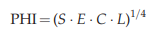

*PHI is a geometric mean of the four parameters*

PHI uses parameters that are observablly unavailable in vast majority of datasets, since it requires detailed knowledge than avaliable 

---

## Biological Complexity Index - BCI

Based on PHI, another index was introduced by adding three more parameters: geophysical complexity, appropriate temperature and age, called **Biological Complexity Index - BCI**

In the seven parameters, due to lack of information two of the parameters: chemical composition and existance of liquid medium, were dropper and BCI was formulated only using 5 parameters

Formula:

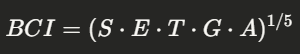

BCI requires geophysical complexity, whose data requires knowledge of plate tectonic activity, volcanism, and internal heat flux — none of which are measurable from remote observations of exoplanets.

---

## **SEPHI - Statistical Likelihood Exo-Planetary Habitability Index**

SEPHI is a direct response to the weakness of PHI and BCI, it is a liklihood function rather than a discrete quatized score
Instead of a planet either "passing" or "failing" a temperature threshold, it receives a score that reflects how close it is to the optimal value, which is physically more honest and statistically more meaningful

Formula:

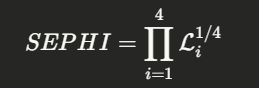

The four sub-indexes are: 
* L1(telluric likelihood — is the planet rocky?), 
* L2 (atmosphere retention and surface gravity), 
* L3 (liquid water potential, combining temperature and orbital position), and 
* L4 (magnetic field likelihood, protecting the surface from stellar radiation). 

Each Li is computed using a Gaussian-like profile centered on Earth's reference value for that property.

SEPHI is the most rigorous habitability index, its sub-index require data that are already available in my dataset if they are to be derived.

The magnetic field sub-index is approximated in this analysis from planetary mass and system age due to the unavailability of rotation rate data, a limitation that is explicitly acknowledged.

---

## SEPHI 2.0

 SEPHI 2.0 is a revised and improved version of SEPHI, published by Rodríguez-Mozos & Moya in a subsequent paper. It incorporates three key methodological improvements over the original: updated scaling laws for estimating exoplanet internal structures and magnetic field strength, the inclusion of orbital eccentricity in the liquid water sub-index (since a highly eccentric orbit can periodically push a planet outside its habitable zone even if its semi-major axis falls within it), and an updated mass-radius relationship for converting between observable and derived planetary properties.

 Formula: SEPHI 2.0 retains the four sub-indexes of the original but changes the aggregation method fundamentally. Rather than taking the geometric mean, it selects the most restrictive sub-index

 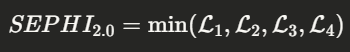

 The motivation is that the geometric mean can obscure a critical failure — a planet that scores 0.9 on three sub-indexes but 0.05 on atmosphere retention receives a geometric mean of approximately 0.52, suggesting moderate habitability, when in reality the absence of an atmosphere makes it almost certainly uninhabitable.

 Despite its methodological superiority, SEPHI 2.0 was not implemented in this analysis for two practical reasons. First, orbital eccentricity (pl_orbeccen) is missing for a substantial fraction of planets in the NASA Exoplanet Archive, which would significantly reduce the sample size if required as a mandatory input. Second, the updated magnetic field scaling laws in SEPHI 2.0 require planetary rotation rates, which are unmeasured for the overwhelming majority of known exoplanets. The original SEPHI was therefore used as a methodologically sound and data-compatible alternative. The geometric mean limitation identified by SEPHI 2.0 is explicitly acknowledged as a known limitation of this analysis, and the minimum sub-index approach of SEPHI 2.0 is recommended as a direction for future work when more complete observational data becomes available.

 ---

In [42]:
def calculate_sephi(pl_dens, pl_escvel, pl_eqt, hzd, pl_bmasse, st_age):

    # --- L1: Telluric likelihood ---
    # pl_dens is in g/cm3, convert to Earth units (Earth = 5.51 g/cm3)
    # Gaussian peaks at 1.0 Eu — Earth-like rocky density
    density_eu = pl_dens / 5.51
    L1 = np.exp(-((density_eu - 1.0) ** 2) / (2 * 0.3 ** 2))

    # --- L2: Atmosphere retention likelihood ---
    # pl_escvel is in m/s, convert to Earth units (Earth = 11186 m/s)
    # Gaussian peaks at 1.0 Eu — Earth-like escape velocity
    escvel_eu = pl_escvel / 11186.0
    L2 = np.exp(-((escvel_eu - 1.0) ** 2) / (2 * 0.3 ** 2))

    # --- L3: Liquid water likelihood ---
    # Combines temperature and habitable zone position
    # Temperature: asymmetric Gaussian centered at 273 K (freezing point)
    # Falls off faster below 273 K (frozen) than above (still liquid)
    if pl_eqt >= 273:
        temp_score = np.exp(-((pl_eqt - 273) ** 2) / (2 * 50 ** 2))
    else:
        temp_score = np.exp(-((pl_eqt - 273) ** 2) / (2 * 30 ** 2))

    # HZD score: already normalized 0-1, peaks at habitable zone center
    hzd_score = max(0, 1 - abs(hzd))
    L3 = temp_score * hzd_score

    # --- L4: Magnetic field likelihood ---
    # Approximated from mass and stellar age (rotation rate unavailable)
    # pl_bmasse already in Earth masses — peaks at 1.5 Eu
    mass_score = np.exp(-((pl_bmasse - 1.5) ** 2) / (2 * 1.5 ** 2))

    # st_age already in Gy — peaks at 4.5 Gy (Solar System age)
    if not np.isnan(st_age):
        age_score = np.exp(-((st_age - 4.5) ** 2) / (2 * 3.0 ** 2))
    else:
        age_score = 0.5  # neutral value when age is unknown
    L4 = mass_score * age_score

    # --- SEPHI: geometric mean of four sub-indexes ---
    # All four conditions must be simultaneously satisfied
    sephi = (L1 * L2 * L3 * L4) ** (1/4)

    return sephi


sephi_vec = np.vectorize(calculate_sephi)
esi_hzd_df['sephi'] = sephi_vec(
    esi_hzd_df['pl_dens'],
    esi_hzd_df['pl_escvel'],
    esi_hzd_df['pl_eqt'],
    esi_hzd_df['hzd'],
    esi_hzd_df['pl_bmasse'],
    esi_hzd_df['st_age']
)

In [43]:
esi_hzd_df.columns

Index(['pl_name', 'pl_rade', 'pl_bmasse', 'pl_eqt', 'st_lum', 'st_rad',
       'st_teff', 'pl_orbsmax', 'pl_orbper', 'st_mass', 'st_age', 'pl_escvel',
       'pl_dens', 'esi', 'hzd', 'sephi'],
      dtype='object')

---

To produce a single, unified habitability metric, we combine the three independent indices (ESI, HZD, and SEPHI) using a geometric mean:

Formula:

`Final Score = (ESI × HZD × SEPHI)^(1/3)`

the following physically motivated reasons:

1. Multiplicative Dependencies in Habitability
    Habitability factors are not independent—they interact multiplicatively rather than additively. A planet must satisfy ALL conditions simultaneously for life to exist:

Liquid water requires both appropriate temperature (ESI) AND orbital position (HZD)
Atmosphere retention (SEPHI) is meaningless without a habitable temperature range
A planet scoring perfectly on two metrics but failing on one is uninhabitable
The geometric mean naturally captures this "all conditions must be met" requirement through multiplication, while the cube root normalization keeps scores in an interpretable 0-1 range.

2. Consistency with Established Indices
    Both ESI and SEPHI internally use geometric means to combine their sub-components:

ESI: Combines radius, density, escape velocity, and temperature via geometric mean (Schulze-Makuch et al., 2011)
SEPHI: Combines four sub-indexes (L1, L2, L3, L4) via geometric mean (Rodríguez-Mozos & Moya, 2017)
Using a geometric mean for the final score maintains methodological consistency with the underlying indices and ensures comparability with existing habitability literature.

3. Balanced Sensitivity to Low Scores
    The geometric mean penalizes low scores more severely than an arithmetic mean, but less harshly than taking the minimum:

Method	Example: (0.9, 0.9, 0.1)	Interpretation

`Arithmetic mean	(0.9 + 0.9 + 0.1)/3 = 0.63	Masks critical failure`

`Geometric mean	(0.9 × 0.9 × 0.1)^(1/3) = 0.39	Appropriately penalizes`

`Minimum	min(0.9, 0.9, 0.1) = 0.1	Overly harsh`

The geometric mean strikes a balance: it significantly reduces the score when any factor is poor, but still rewards planets that perform well on multiple metrics.

4. Scale Preservation
    The cube root normalization ensures the final score remains in the [0, 1] range:

A planet scoring 1.0 on all three metrics receives a final score of 1.0 (perfect habitability)
A planet scoring 0.0 on any metric receives a final score of 0.0 (uninhabitable)
Intermediate scores remain interpretable as "fraction of Earth-like habitability"
This makes the final score directly comparable to ESI and other established metrics.

In [44]:
def calculate_final_score(esi, hzd, sephi):
    # All three tiers must be satisfied simultaneously
    final_score = (esi * hzd * sephi) ** (1/3)
    return final_score

score_vec = np.vectorize(calculate_final_score)
esi_hzd_df['final_score'] = score_vec(
    esi_hzd_df['esi'],
    esi_hzd_df['hzd'],
    esi_hzd_df['sephi']
)

In [45]:
final_list = esi_hzd_df[['pl_name', 'esi', 'hzd', 'sephi', 'final_score']]\
    .sort_values('final_score', ascending=False)\
    .reset_index(drop=True)

print(final_list.head(15))

         pl_name       esi       hzd     sephi  final_score
0    Wolf 1069 b  0.974170  0.895218  0.439464     0.726377
1   TRAPPIST-1 e  0.951359  0.903434  0.418512     0.711185
2   Kepler-442 b  0.912707  0.826603  0.446657     0.695880
3      GJ 1002 b  0.926202  0.864048  0.394915     0.681160
4  Proxima Cen b  0.889379  0.909200  0.299800     0.623533
5      TOI-715 b  0.854830  0.807265  0.347039     0.621000
6     GJ 667 C f  0.835860  0.968433  0.199229     0.544317
7      GJ 1061 d  0.873787  0.999570  0.087003     0.423563


`Research on final candidates - Pending`